In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from plt_one_addpt_onclick import plt_one_addpt_onclick
%matplotlib inline
plt.style.use("./deeplearning.mplstyle")

In [17]:
def draw_vthresh(ax, x):
    #Draws a threshold at 0.5
    ylim = ax.get_ylim()
    xlim = ax.get_xlim()
    ax.fill_between([xlim[0], x], [ylim[1], ylim[1]], alpha = 0.2, color = 'r')
    ax.fill_between([x, xlim[0]], [ylim[1], ylim[1]], alpha = 0.2, color = 'r' )
    
    ax.annotate("z >= 0", xy = [x, 0.5], xycoords = 'data', xytext = [30, 5], textcoords = 'offset points')
    d = FancyArrowPatch(posA = (x, 0.5), posB = (x + 3, 0.5), color = 'r', arrowstyle = "simple, head_width = 5, head_length = 10, tail_width = 0.0", )
    ax.add_artist(d)

    ax.annotate("z < 0", xy = [x, 0.5], xycoords = 'data', xytext = [-50, 5], textcoords = "offset points", ha = 'left')
    f = FancyArrowPatch(posA = (x, 0.5), posB = (x - 3, 0.5), color = 'b', arrowstyle = "simple, head_width = 5, head_length = 10, tail_width = 0.0", )
    ax.add_artist(f)

## Sigmoid Function
Start by using the linear regression model:
$f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \mathbf{w} \cdot  \mathbf{x}^{(i)} + b$, to predict $y$ given $x$.

But the output must be between $0$ and $1$. So, we use the sigmoid function.

Sigmoid Function Formula:

$g(z) = \frac{1}{1+e^{-z}}\tag{1}$

where, $g(z) = \mathbf{w} \cdot  \mathbf{x}^{(i)} + b$

- In the case of a single example, $z$ is scalar.
- In case of multiple examples, $z$ may be a vector consisting of $m$ values, one for each example.
- The implementation of the Sigmoid Function should cover both these potential input formats.
- NumPy has a function $.exp()$, which offers a convenient way to calculate the exponential ($e^z$) for all elements in the input array ($z$). It also works with single number input.

In [18]:
#Array Input
input_array = np.array([1, 2, 3, 4, 5])
exp_array = np.exp(input_array)
print("Input to exp: ", input_array)
print("Output of exp: ", exp_array)

Input to exp:  [1 2 3 4 5]
Output of exp:  [  2.718   7.389  20.086  54.598 148.413]


In [19]:
#Single number input
val = 5
exp_val = np.exp(val)
print("Input to exp: ", val)
print("Output of exp: ", exp_val)

Input to exp:  5
Output of exp:  148.4131591025766


## Implementation of Sigmoid Function

In [20]:
def sigmoid(z):
    """
    Compute the sigmmmoid of z
    Args:
        z (ndarrays): A scalar, numpy array of any size
    Returns:
        g (ndarray): sigmoid(z), with the same shape as z
    """

    g = 1 / (1 + np.exp(-z))
    return g

## Output of Sigmoid Function

In [21]:
#generate an array
z_tmp = np.arange(-10, 11)

y = sigmoid(z_tmp)

np.set_printoptions(precision = 3)
print("Input (z), Output (Sigmoid(z))")
print(np.c_[z_tmp, y])

Input (z), Output (Sigmoid(z))
[[-1.000e+01  4.540e-05]
 [-9.000e+00  1.234e-04]
 [-8.000e+00  3.354e-04]
 [-7.000e+00  9.111e-04]
 [-6.000e+00  2.473e-03]
 [-5.000e+00  6.693e-03]
 [-4.000e+00  1.799e-02]
 [-3.000e+00  4.743e-02]
 [-2.000e+00  1.192e-01]
 [-1.000e+00  2.689e-01]
 [ 0.000e+00  5.000e-01]
 [ 1.000e+00  7.311e-01]
 [ 2.000e+00  8.808e-01]
 [ 3.000e+00  9.526e-01]
 [ 4.000e+00  9.820e-01]
 [ 5.000e+00  9.933e-01]
 [ 6.000e+00  9.975e-01]
 [ 7.000e+00  9.991e-01]
 [ 8.000e+00  9.997e-01]
 [ 9.000e+00  9.999e-01]
 [ 1.000e+01  1.000e+00]]


## Plotting Sigmoid Function

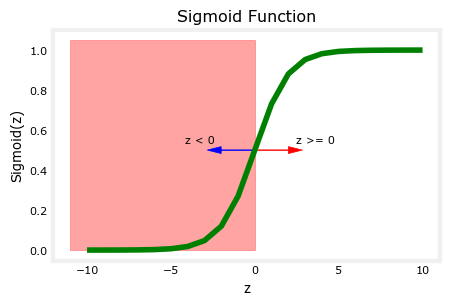

In [24]:
plt.close('all')
fig, ax = plt.subplots(1,1, figsize = (5, 3))
ax.plot(z_tmp, y, c = 'g')
ax.set_title("Sigmoid Function")
ax.set_xlabel("z")
ax.set_ylabel("Sigmoid(z)")
draw_vthresh(ax, 0)
plt.show()